<a href="https://colab.research.google.com/github/UROOJKHANdev/ARTIFICIAL_INTELLIGENCE-AND-DATA-SCIENCE-MODELS-/blob/main/SUPPORT_VECTOR_MACHINE_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [31]:
df = pd.read_csv("/content/heart_disease_health_indicators_BRFSS2015.csv")

df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [32]:
df.shape

(253680, 22)

In [33]:
df.columns

Index(['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [35]:
df.isnull().sum()

,0
HeartDiseaseorAttack,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
Diabetes,0
PhysActivity,0
Fruits,0


In [36]:
df.duplicated().sum()

np.int64(23899)

In [37]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 23899


In [38]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (229781, 22)


In [39]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [40]:
df.describe()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,229781.000000,229781.000000,229781.000000,229781.000000,229781.00000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,...,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000
mean,0.103216,0.454441,0.441760,0.959535,28.68567,0.465661,0.044756,0.325627,0.733355,0.612966,...,0.946075,0.092810,2.601151,3.505373,4.675178,0.185507,0.439231,8.086582,4.980568,5.890383
std,0.304241,0.497921,0.496598,0.197047,6.78636,0.498821,0.206767,0.724623,0.442206,0.487073,...,0.225871,0.290167,1.064685,7.713725,9.046568,0.388709,0.496295,3.093809,0.992895,2.092477
min,0.000000,0.000000,0.000000,0.000000,12.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.00000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,6.000000
75%,0.000000,1.000000,1.000000,1.000000,32.00000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,4.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.00000,1.000000,1.000000,2.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [41]:
print(df['HeartDiseaseorAttack'].value_counts())

HeartDiseaseorAttack
0.0    206064
1.0     23717
Name: count, dtype: int64


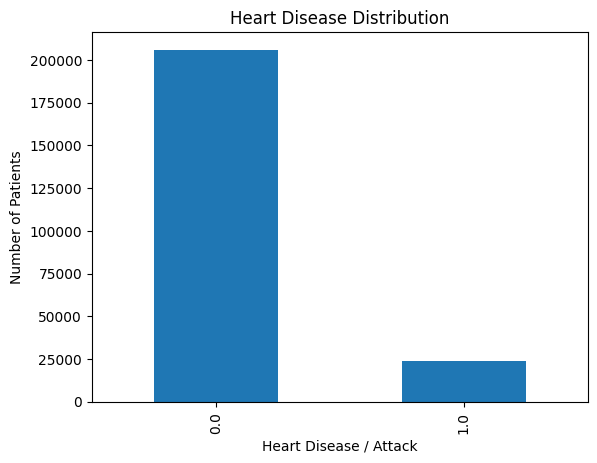

In [42]:
import matplotlib.pyplot as plt

df['HeartDiseaseorAttack'].value_counts().plot(kind='bar')

plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease / Attack')
plt.ylabel('Number of Patients')

plt.show()

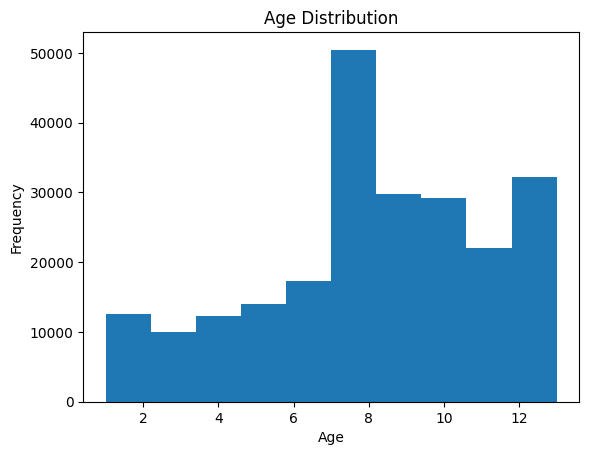

In [43]:
plt.hist(df['Age'], bins=10)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

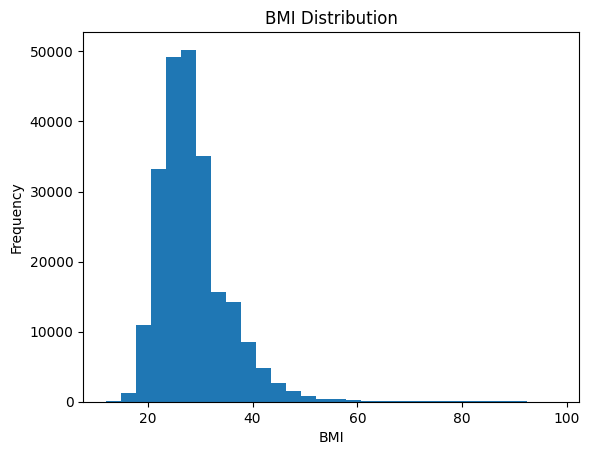

In [44]:
plt.hist(df['BMI'], bins=30)

plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')

plt.show()

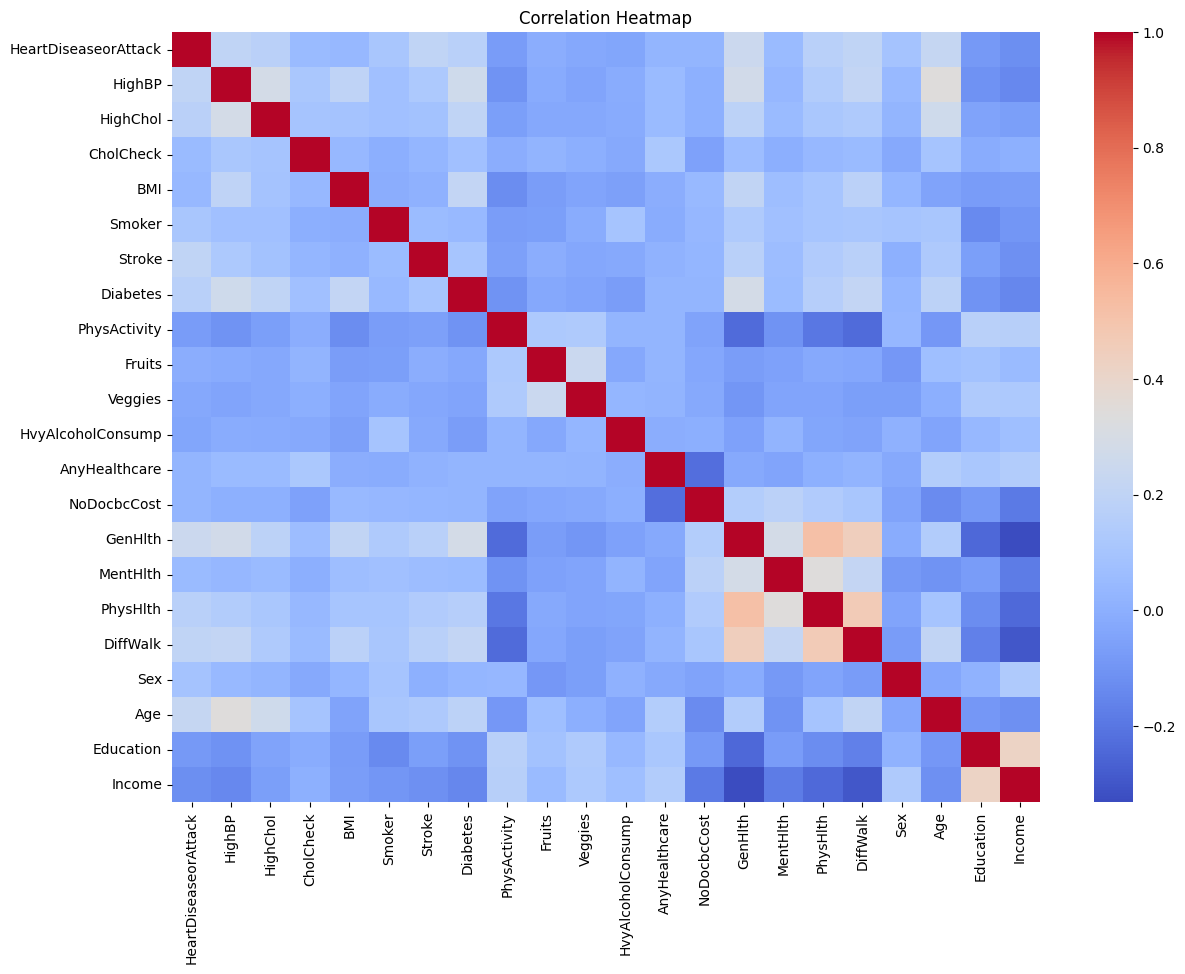

In [45]:
import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')
plt.show()

In [46]:
X = df.drop('HeartDiseaseorAttack', axis=1)
y = df['HeartDiseaseorAttack']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (229781, 21)
y Shape: (229781,)


In [47]:
import numpy as np

print("NaN values:", X.isnull().sum().sum())
print("Infinity values:", np.isinf(X).sum().sum())

NaN values: 0
Infinity values: 0


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (183824, 21)
X_test: (45957, 21)
y_train: (183824,)
y_test: (45957,)


In [49]:
from sklearn.svm import LinearSVC

model = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)
print(model)


LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
model.fit(X_train_scaled, y_train)

print("SVM Model Training Completed!")

SVM Model Training Completed!


In [54]:
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1.]


In [55]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7341863045890724

Confusion Matrix:
[[30015 11199]
 [ 1017  3726]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.73      0.83     41214
         1.0       0.25      0.79      0.38      4743

    accuracy                           0.73     45957
   macro avg       0.61      0.76      0.60     45957
weighted avg       0.89      0.73      0.78     45957



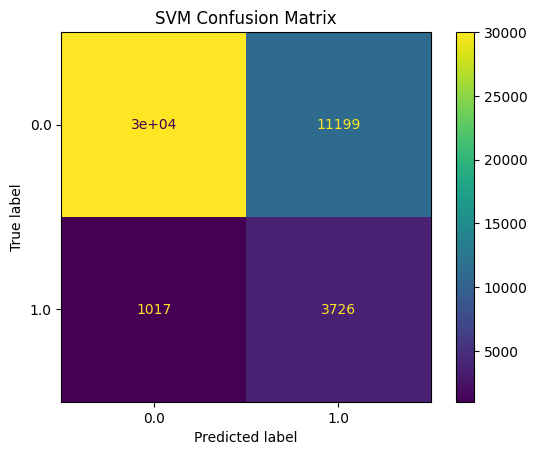

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("SVM Confusion Matrix")
plt.show()

In [59]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LinearSVC(
        class_weight='balanced',
        random_state=42,
        max_iter=5000
    ),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 1}
Best CV Score: 0.38146668633294284


In [60]:
best_model = grid.best_estimator_

print(best_model)

LinearSVC(C=1, class_weight='balanced', max_iter=5000, random_state=42)


In [61]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.73458452 0.73654291 0.7369509  0.73262614 0.73911979]
Mean CV Accuracy: 0.7359648530928389


In [62]:
f1_scores = cross_val_score(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("F1 Scores:", f1_scores)
print("Mean F1 Score:", f1_scores.mean())

F1 Scores: [0.37973557 0.38258542 0.38444402 0.37769055 0.383889  ]
Mean F1 Score: 0.3816689114104841


In [63]:
from sklearn.pipeline import Pipeline

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(
        class_weight='balanced',
        random_state=42,
        max_iter=5000
    ))
])

svm_pipeline.fit(X_train, y_train)

print("Pipeline Training Completed!")

Pipeline Training Completed!


In [64]:
pipeline_pred = svm_pipeline.predict(X_test)

print("Pipeline Accuracy:",
      accuracy_score(y_test, pipeline_pred))

Pipeline Accuracy: 0.7341863045890724


In [65]:
print(classification_report(y_test, pipeline_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.73      0.83     41214
         1.0       0.25      0.79      0.38      4743

    accuracy                           0.73     45957
   macro avg       0.61      0.76      0.60     45957
weighted avg       0.89      0.73      0.78     45957



In [66]:
import joblib

joblib.dump(
    svm_pipeline,
    'heart_disease_svm_pipeline.pkl'
)

print("Model saved successfully!")

Model saved successfully!


In [67]:
loaded_model = joblib.load(
    'heart_disease_svm_pipeline.pkl'
)

print("Model loaded successfully!")

Model loaded successfully!


In [68]:
new_prediction = loaded_model.predict(X_test.iloc[[0]])

print("Prediction:", new_prediction[0])

Prediction: 0.0
